In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")

from BIGFAM import obj2, tools
import importlib

# Step 1. Load data

In [2]:
# load FR-reg
frreg_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/frreg/REL"
fns = os.listdir(frreg_path)
len(fns)

40

In [46]:
for ii, fn in enumerate(tqdm(fns)):
    pheno = fn.split(".")[0]
    print(f"[{ii+1}/{len(fns)}] {pheno}")
    
    # load FR-reg results
    df_frreg = pd.read_csv(f"{frreg_path}/{fn}", 
                           delim_whitespace=True)
    if ii == 22:
        break


 55%|█████▌    | 22/40 [00:00<00:00, 421.16it/s]

[1/40] avg_dia
[2/40] height
[3/40] weight
[4/40] max_leg
[5/40] avg_hr
[6/40] avg_sys
[7/40] PR_interval
[8/40] Glucose
[9/40] HDL_cholesterol
[10/40] Total_cholesterol
[11/40] QT_interval
[12/40] Sodium
[13/40] FEV
[14/40] QRS_axis
[15/40] absi
[16/40] Heart_Rate
[17/40] max_arm
[18/40] ratio
[19/40] hips
[20/40] Creat_mgdl
[21/40] max_sys
[22/40] Potassium
[23/40] FVC


In [64]:
df_frreg.groupby("DOR")["n"].mean()

DOR
1    3784.000000
2     359.733333
3     153.000000
Name: n, dtype: float64

In [74]:
df_lmbds = obj2._resamplingFRregCoefficients(df_frreg)
df_lmbds = df_lmbds[df_lmbds["DOR"] != 3]

In [75]:
alpha_dicts={"type": "eta", "weight":-2}

df_raw = pd.DataFrame(columns=["eta", "alpha", "Xmale", "Xfemale"])
for ib in range(100):
    df_block = df_lmbds[df_lmbds["block"] == ib].copy()
    # compute FRresidual & eta
    df_block = obj2._regressOutMean(df_block, bin=["DOR", "sex_type"])
    
    # L2 weight value
    mean_eta = df_block["eta"].mean()
    if alpha_dicts["type"] == "eta":
        alpha = mean_eta**alpha_dicts["weight"]
    else:
        alpha = alpha_dicts["weight"]
    
    if alpha < 0:
        print("L2 weight is negative...", flush=True)
        continue
    # alpha = 0
    # estimate X
    MODEL = obj2._optToFindXmXf(df_block, alpha)
    df_raw.loc[len(df_raw)] = [mean_eta, alpha, MODEL.x[0], MODEL.x[1]]
    
    # for r0 in np.linspace(-1, 1, 11):
    #     MODEL = obj2._optToFindXmXfR(df_block, alpha, r0)
    #     df_raw.loc[len(df_raw)] = [ib, mean_eta, alpha, MODEL.x[0], MODEL.x[1], r0, MODEL.fun]

    break

df_raw
        

,eta,alpha,Xmale,Xfemale
0,0.484507,4.259903,0.000001,0.000001


In [76]:
import seaborn as sns

In [77]:
df_block

,DOR,relationship,sex_type,Erx,slope,block,eta,residual,tl
0,1,DF,FM,0.707107,0.216509,0,0.506111,-0.036546,1.178511e-01
100,1,DM,FF,0.500000,0.242062,0,0.582891,-0.049383,-1.250000e-01
200,1,DS,FF,0.750000,0.340829,0,0.582891,0.049383,1.250000e-01
300,1,SB,MM,0.500000,0.347566,0,0.614187,0.040473,2.500000e-01
400,1,SF,MM,0.000000,0.266621,0,0.614187,-0.040473,-2.500000e-01
500,1,SM,FM,0.707107,0.230715,0,0.506111,-0.022341,1.178511e-01
600,1,SS_DB,FM,0.353553,0.311942,0,0.506111,0.058887,-2.357023e-01
700,2,DF_DF,FF,0.500000,0.425006,0,0.461863,0.309540,1.250000e-01
800,2,DF_DM,FM,0.353553,-0.440425,0,0.302172,-0.515968,1.325825e-01
900,2,DF_SB,FM,0.353553,0.116873,0,0.302172,0.041330,1.325825e-01


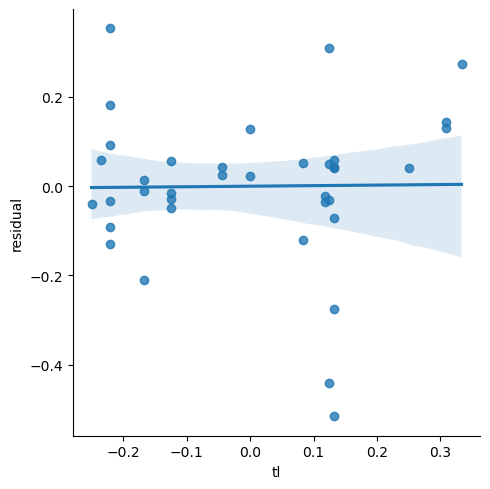

In [79]:
sns.lmplot(
    data=df_block,
    x="tl",
    y="residual",
)

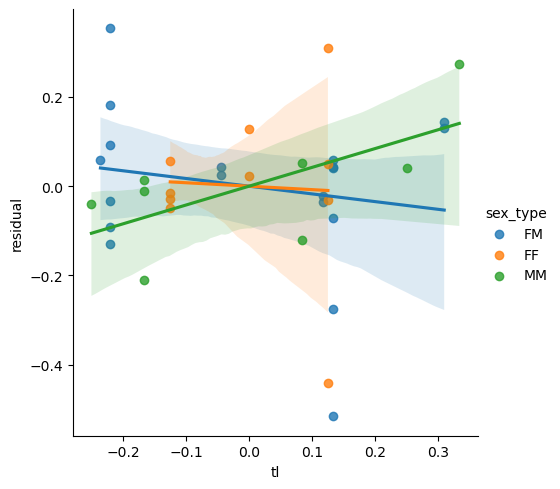

In [78]:
sns.lmplot(
    data=df_block,
    x="tl",
    y="residual",
    hue="sex_type"
)